In [1]:
# %%
import sys
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import logging

sys.path.insert(0, '/home/sandeep/DSIPTS_PTF')

from dsipts.data_structure.d1_layers.multi_source_csv import MultiSourceTSDataSet
from dsipts.data_structure.d2_layers.encoder_decoder import EncoderDecoder
from dsipts.data_management.public_datasets import read_public_dataset

logging.basicConfig(level=logging.INFO)
print(f"✅ PyTorch {torch.__version__}, CUDA: {torch.cuda.is_available()}")

/home/sandeep/DSIPTS_PTF/.venv/lib/python3.12/site-packages/lightning_fabric/__init__.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)


✅ PyTorch 2.9.0+cu128, CUDA: False


In [2]:
data_path = '/home/sandeep/DSIPTS_PTF/data/'
weather_path = data_path + 'weather.csv'

# Load data
dataset = pd.read_csv(weather_path)
dataset.rename(columns={'date': 'time'}, inplace=True)  # Only rename date, keep OT as is
dataset['time'] = pd.to_datetime(dataset['time'])

weather_data = dataset
target_col = 'OT'  # Use original target name
covariate_columns = list(set(dataset.columns).difference(set(['time', target_col])))

print(f"✅ Dataset loaded: {weather_data.shape}")
print(f"   Columns: {list(weather_data.columns)}")
print(f"   Target: {target_col}")
print(f"   Covariates: {covariate_columns}")
print(f"   Time range: {weather_data['time'].min()} to {weather_data['time'].max()}")

✅ Dataset loaded: (52696, 22)
   Columns: ['time', 'p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)', 'rain (mm)', 'raining (s)', 'SWDR (W/m�)', 'PAR (�mol/m�/s)', 'max. PAR (�mol/m�/s)', 'Tlog (degC)', 'OT']
   Target: OT
   Covariates: ['rh (%)', 'max. wv (m/s)', 'Tlog (degC)', 'Tdew (degC)', 'PAR (�mol/m�/s)', 'p (mbar)', 'wv (m/s)', 'sh (g/kg)', 'H2OC (mmol/mol)', 'wd (deg)', 'rho (g/m**3)', 'max. PAR (�mol/m�/s)', 'T (degC)', 'raining (s)', 'Tpot (K)', 'rain (mm)', 'VPdef (mbar)', 'VPmax (mbar)', 'SWDR (W/m�)', 'VPact (mbar)']
   Time range: 2020-01-01 00:10:00 to 2021-01-01 00:00:00


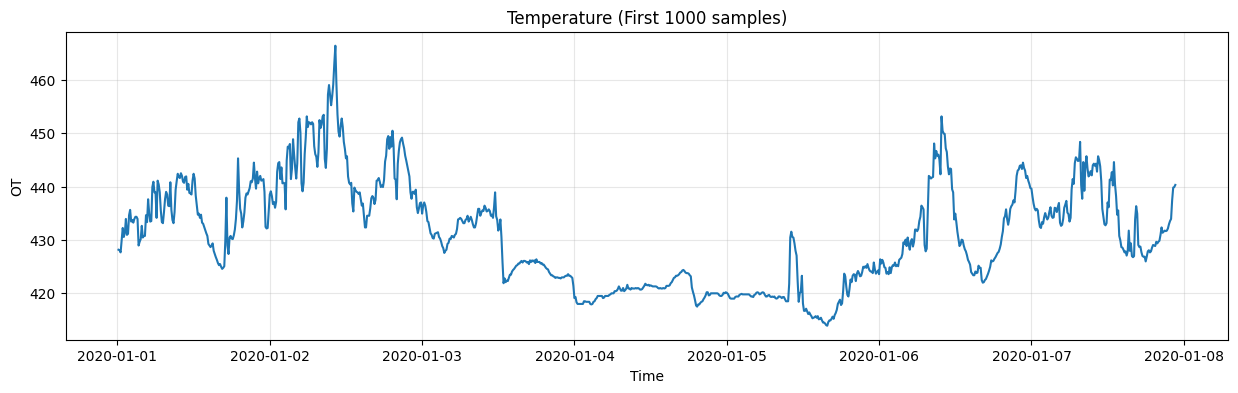

In [3]:
# Visualize target
plt.figure(figsize=(15, 4))
plt.plot(weather_data['time'][:1000], weather_data['OT'][:1000])
plt.title('Temperature (First 1000 samples)')
plt.xlabel('Time')
plt.ylabel('OT')
plt.grid(True, alpha=0.3)
plt.show()

In [4]:
from utils import explore_data
#explore_data(weather_data)

### 3. D1 Layer: Preprocessing

In [5]:
'y' in weather_data.columns

False

In [6]:
# create a temp data slice for faster testing
sliced_weather_path = data_path+'_sliced.csv'
weather_data[:1000].to_csv( sliced_weather_path,index=False) 
df = pd.read_csv(sliced_weather_path)
print(df.shape, weather_data.shape)
df.columns  == weather_data.columns

(1000, 22) (52696, 22)


array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True])

In [7]:
grouped_weather_path = data_path + '_grouped.csv'

# Define groups with specific probabilities
groups_list = ['Group1', 'Group2', 'Group3', 'Group4']
probabilities = [0.1, 0.1, 0.1, 0.7]  # Custom probabilities

# Add random group column with controlled distribution
weather_data_grouped = weather_data.assign(
    group=np.random.choice(groups_list, size=len(weather_data), p=probabilities)
)

# Save and verify
weather_data_grouped.to_csv(grouped_weather_path, index=False)
df = pd.read_csv(grouped_weather_path)

print(f"Weather data shape: {weather_data.shape}")
print(f"Grouped data shape: {df.shape}")
print(f"Columns match: {df.columns.tolist() == weather_data_grouped.columns.tolist()}")
print(f"Group distribution:\n{df['group'].value_counts()}")
print(f"Group percentages:\n{df['group'].value_counts(normalize=True) * 100}")


Weather data shape: (52696, 22)
Grouped data shape: (52696, 23)
Columns match: True
Group distribution:
group
Group4    36908
Group1     5336
Group2     5248
Group3     5204
Name: count, dtype: int64
Group percentages:
group
Group4    70.039472
Group1    10.126006
Group2     9.959010
Group3     9.875512
Name: proportion, dtype: float64


In [8]:
grouped_weather_path, sliced_weather_path, weather_path

('/home/sandeep/DSIPTS_PTF/data/_grouped.csv',
 '/home/sandeep/DSIPTS_PTF/data/_sliced.csv',
 '/home/sandeep/DSIPTS_PTF/data/weather.csv')

In [9]:
weather_data_grouped.columns

Index(['time', 'p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)',
       'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)',
       'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)',
       'wd (deg)', 'rain (mm)', 'raining (s)', 'SWDR (W/m�)',
       'PAR (�mol/m�/s)', 'max. PAR (�mol/m�/s)', 'Tlog (degC)', 'OT',
       'group'],
      dtype='object')

In [10]:
print("STEP 1: Initialize D1 Layer")
print("="*80)

d1_dataset = MultiSourceTSDataSet(
    file_paths=[grouped_weather_path],
    time_col='time',
    target_cols=[target_col],  # Use 'OT' as target
    num_cols=covariate_columns,  # Specify numerical columns
    enrich_cat=['hour', 'dow'],
    global_forecasting=False,
    group_cols=['group'],  # No groups for local forecasting
    memory_efficient=False,
    add_target_to_past=True,  # Include target in past features (default)
)

print(f"\n✅ D1 Layer initialized")
print(d1_dataset.metadata)
print(f"   Groups: {len(d1_dataset._group_ids)}")
print(f"   Target cols: {d1_dataset.target_cols}")
print(f"   Feature cols: {len(d1_dataset.feature_cols)} features")
print(f"   Num cols: {len(d1_dataset.num_cols)} numerical")
print(f"   Cat cols: {len(d1_dataset.cat_cols)} categorical")
print(f"   Global forecasting: {d1_dataset.global_forecasting}")
print(f"   Group cols: {d1_dataset.group_cols}")

INFO:dsipts.data_structure.d1_layers.multi_source_csv:Processing files to build metadata...
INFO:dsipts.data_structure.d1_layers.multi_source_csv:Processing file 1/1: /home/sandeep/DSIPTS_PTF/data/_grouped.csv


STEP 1: Initialize D1 Layer


INFO:dsipts.data_structure.d1_layers.multi_source_csv:Processed 4 groups from 1 sources



✅ D1 Layer initialized
{'n_targets': 1, 'n_features': 24, 'n_categorical': 3, 'n_past': 3, 'n_future': 2, 'target_cols': ['OT'], 'feature_cols': ['group', 'rh (%)', 'max. wv (m/s)', 'Tlog (degC)', 'Tdew (degC)', 'PAR (�mol/m�/s)', 'p (mbar)', 'wv (m/s)', 'sh (g/kg)', 'H2OC (mmol/mol)', 'wd (deg)', 'rho (g/m**3)', 'max. PAR (�mol/m�/s)', 'T (degC)', 'raining (s)', 'Tpot (K)', 'rain (mm)', 'VPdef (mbar)', 'VPmax (mbar)', 'SWDR (W/m�)', 'VPact (mbar)', 'OT', 'hour', 'dow'], 'idx_categorical': [0, 22, 23], 'idx_past': [0, 22, 23], 'idx_future': [22, 23], 'idx_targets': [21], 'n_groups': 4, 'time_col': 'time', 'past_cols': ['group', 'hour', 'dow'], 'future_cols': ['hour', 'dow'], 'enrich_cat': ['hour', 'dow'], 'categorical_columns': ['group', 'hour', 'dow'], 'cat_cols_list': ['group', 'hour', 'dow'], 'cat_cardinalities': [4, 24, 7], 'group_mapping': {('Group1',): 0, ('Group2',): 1, ('Group3',): 2, ('Group4',): 3}, 'reverse_mapping': {0: ('Group1',), 1: ('Group2',), 2: ('Group3',), 3: ('Gro

In [11]:
sample = d1_dataset[0]
print(f"\n   Sample keys: {list(sample.keys())}")
for k, v in sample.items():
    if isinstance(v, torch.Tensor):
        print(f"     {k}: {v.shape}")
    elif isinstance(v, (int, float)):
        print(f"     {k}: {v}")


   Sample keys: ['x', 'y', 'group_id', 'time', 'seq_len']
     x: torch.Size([5336, 24])
     y: torch.Size([5336, 1])
     group_id: 0
     seq_len: 5336


In [12]:
#d1_dataset.group_info

### 4. D2 Layer: Encoder-Decoder

#### Scaling with memo_eff = True

In [13]:
d1_dataset.metadata['reverse_mapping']

{0: ('Group1',), 1: ('Group2',), 2: ('Group3',), 3: ('Group4',)}

In [14]:
d1_dataset.group_cols

['group']

In [15]:
print("STEP 2: Initialize D2 Layer (Scaler NOT fitted yet)")
print("="*80)
import time
start = time.time()
d2_dataset = EncoderDecoder(
    d1_dataset=d1_dataset,
    past_len=96,           # Use 96 hours (4 days) of past data
    future_len=96,         # Predict 96 hours (4 days) ahead
    step_size=96,
    batch_size=32,
    split_ratio=(0.7, 0.15, 0.15),  # NEW: Separate ratio parameter
    #split_group_config=(),
    scaling_method='standard',
    scale_targets=True
)
elapsed_init = time.time() - start

print(f"\n✅ D2 Layer initialized in {elapsed_init:.3f}s")
print(f"   Valid windows: {len(d2_dataset.valid_windows)}")
print(f"   Global forecasting: {d2_dataset.global_forecasting}")
print(f"   Split ratio: {d2_dataset.split_ratio}")
print(f"   Split group config: {d2_dataset.split_group_config}")

INFO:dsipts.data_structure.d2_layers.encoder_decoder:Global forecasting mode: False
INFO:dsipts.data_structure.d2_layers.encoder_decoder:Memory efficient mode: False
INFO:dsipts.data_structure.d2_layers.utils:Created 543 windows from 4 groups


STEP 2: Initialize D2 Layer (Scaler NOT fitted yet)


INFO:dsipts.data_structure.d2_layers.encoder_decoder:Initialized with 543 windows



✅ D2 Layer initialized in 0.128s
   Valid windows: 543
   Global forecasting: False
   Split ratio: (0.7, 0.15, 0.15)
   Split group config: None


In [16]:
d1_dataset.target_cols[0]

'OT'

In [17]:
#metadata = getattr(d1_dataset, 'metadata', {})

In [18]:
print(f"   Train dataset: {len(d2_dataset.train_dataset) if d2_dataset.train_dataset is not None else 'N/A'}")
print(f"   Validation dataset: {len(d2_dataset.val_dataset) if d2_dataset.val_dataset is not None else 'N/A'}")
print(f"   Test dataset: {len(d2_dataset.test_dataset) if d2_dataset.test_dataset is not None else 'N/A'}")

   Train dataset: N/A
   Validation dataset: N/A
   Test dataset: N/A


In [19]:
train_loader = d2_dataset.train_dataloader()
val_loader = d2_dataset.val_dataloader()
test_loader = d2_dataset.test_dataloader()

In [20]:
d2_dataset.is_scaler_fitted

False

In [21]:
import pytorch_lightning as pl 
class SimpleModel(pl.LightningModule):
    """Simple model for time series forecasting."""
    
    def __init__(self, input_size, output_size, learning_rate=0.001):
        super().__init__()
        print(f"\n[MODEL] Initializing SimpleModel")
        print(f"[MODEL] Input size: {input_size}, Output size: {output_size}, LR: {learning_rate}")
        
        self.save_hyperparameters()
        
        # Simple architecture: Flatten -> Linear
        self.flatten = nn.Flatten()
        self.linear = nn.Linear(input_size, output_size)
        self.criterion = nn.MSELoss()
        
        self.train_losses = []
        self.val_losses = []
        
    def forward(self, x):
        x = self.flatten(x)
        return self.linear(x)
    
    def _common_step(self, batch, stage):
        # Handle both tuple and dict batch formats
        if isinstance(batch, dict):
            # Check for different batch formats
            if 'encoder_cont' in batch:
                # New format with encoder/decoder structure
                x = batch['encoder_cont']  # (B, past_len, n_features)
                y = batch['decoder_target']  # (B, future_len, 1) or (B, future_len)
            elif 'x_num_past' in batch:
                # Old format with separate numerical features
                x = batch['x_num_past']  # (B, past_len, n_features)
                y = batch['y']  # (B, future_len, 1) or (B, future_len)
            else:
                raise ValueError(f"Unknown batch format. Keys: {batch.keys()}")
            
            # Flatten y if needed
            if y.dim() == 3:
                y = y.squeeze(-1)  # (B, future_len)
        else:
            # Tuple format (x, y)
            x, y = batch
        
        y_hat = self(x)
        loss = self.criterion(y_hat, y)
        self.log(f'{stage}_loss', loss, on_epoch=True, prog_bar=True)
        
        if stage == 'train':
            self.train_losses.append(loss.item())
        elif stage == 'val':
            self.val_losses.append(loss.item())
        
        return loss
    
    def training_step(self, batch, batch_idx):
        return self._common_step(batch, 'train')
    
    def validation_step(self, batch, batch_idx):
        return self._common_step(batch, 'val')
    
    def test_step(self, batch, batch_idx):
        return self._common_step(batch, 'test')
    
    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.hparams.learning_rate)

Lets check the input size and initialize the model

In [22]:
import torch.nn as nn
sample_batch = next(iter(train_loader))
if isinstance(sample_batch, dict):
    # Check for different batch formats
    if 'encoder_cont' in sample_batch:
        encoder_cont = sample_batch['encoder_cont']  # (B, past_len, n_features)
        n_features = encoder_cont.shape[-1]
    elif 'x_num_past' in sample_batch:
        # Old format with separate numerical and categorical
        x_num = sample_batch['x_num_past']  # (B, past_len, n_num_features)
        n_features = x_num.shape[-1]
    else:
        raise ValueError(f"Unknown batch format. Keys: {sample_batch.keys()}")
else:
    x, y = sample_batch
    n_features = x.shape[-1]
model = SimpleModel(d2_dataset.past_len*n_features, d2_dataset.future_len)


[MODEL] Initializing SimpleModel
[MODEL] Input size: 2016, Output size: 96, LR: 0.001


In [23]:
from pytorch_lightning import Trainer
trainer = pl.Trainer(
    max_epochs=2,
    accelerator='auto',
    enable_checkpointing=False,
    logger=False,
    num_sanity_val_steps=0,
    enable_progress_bar=True
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


In [24]:
d1_sample = d1_dataset[0]
d1_sample['x'].shape


torch.Size([5336, 24])

In [25]:
trainer.fit(model, d2_dataset)

INFO:dsipts.data_structure.d2_layers.encoder_decoder:[D2 setup] Called with stage='TrainerFn.FITTING'
INFO:dsipts.data_structure.d2_layers.encoder_decoder:[D2 setup] Splits not created. Creating train/val/test splits...
INFO:dsipts.data_structure.d2_layers.encoder_decoder:[D2 split] global_forecasting=False (Local forecasting). Ignoring split_group_config.
INFO:dsipts.data_structure.d2_layers.encoder_decoder:[D2 split] Applying pure temporal split to all windows.
INFO:dsipts.data_structure.d2_layers.encoder_decoder:[D2 split] Temporal split complete: Train=380, Val=81, Test=82
INFO:dsipts.data_structure.d2_layers.encoder_decoder:[D2 setup] Splits created: Train=380, Val=81, Test=82
INFO:dsipts.data_structure.d2_layers.encoder_decoder:[D2 setup] Scaler not fitted. Fitting standard scaler on training data...
INFO:dsipts.data_structure.d2_layers.encoder_decoder:Fitting standard scaler on training windows...
INFO:dsipts.data_structure.d2_layers.encoder_decoder:  Fitting on 380 training win

Epoch 1: 100%|██████████| 15/15 [00:00<00:00, 62.93it/s, loss=0.875, train_loss_step=0.144, val_loss=1.330, train_loss_epoch=1.080]

`Trainer.fit` stopped: `max_epochs=2` reached.


Epoch 1: 100%|██████████| 15/15 [00:00<00:00, 62.32it/s, loss=0.875, train_loss_step=0.144, val_loss=1.330, train_loss_epoch=1.080]


Checks the values after scaling

In [26]:
d2_dataset.is_scaler_fitted

True

In [27]:
batch1 = next(iter(d2_dataset.train_dataloader()))
batch1

{'x_num_past': tensor([[[-1.0572, -1.2004, -1.0058,  ..., -0.6414, -1.4511,  0.0000],
          [-0.8557, -1.2312, -1.0339,  ..., -0.6414, -1.4026,  0.0000],
          [-0.7619, -1.1696, -1.0607,  ..., -0.6414, -1.4000,  0.0000],
          ...,
          [-1.6009, -0.2830,  0.1955,  ..., -0.6133, -1.0985,  0.0000],
          [-1.5716, -0.5374,  0.1379,  ..., -0.6344, -1.1036,  0.0000],
          [-1.5514, -0.4140,  0.0817,  ..., -0.6414, -1.1189,  0.0000]],
 
         [[ 1.1986, -1.1696,  0.5276,  ..., -0.6414,  1.5412,  0.0000],
          [ 1.2306, -1.3160,  0.5236,  ..., -0.6414,  1.5438,  0.0000],
          [ 1.2466, -1.2929,  0.5183,  ..., -0.6414,  1.5463,  0.0000],
          ...,
          [ 0.9641, -0.7687, -1.0875,  ..., -0.6414, -0.7203,  0.0000],
          [ 1.0014, -0.7841, -1.1022,  ..., -0.6414, -0.7254,  0.0000],
          [ 1.0707, -0.4911, -1.1183,  ..., -0.6414, -0.7203,  0.0000]],
 
         [[ 1.3319, -0.8303, -0.1326,  ..., -0.5289,  0.6852,  0.0000],
          [ 0.

Checks the groups in train/test and validation after splititng has taken place to see groups distribution acros these split.s 

In [28]:
if not d2_dataset.splits_created:
    print("Splits not created!")
else:
    print(f'Valid windows in D2: {len(d2_dataset.valid_windows)}')

    all_window_groups = pd.Series(w['group_id'] for w in d2_dataset.valid_windows)
    def get_split_counts(indices, split_name):
        if not indices:
            print("No valid window indices for split: ", split_name)
            return
    
        # using indices to select the gorup names for this split
        group_names_in_split = all_window_groups.iloc[indices]
        #get value counts
        counts = group_names_in_split.value_counts().sort_index()

        #showcase the restuls
        print(f"\n--- {split_name} Split ({len(indices)} windows) ---")
        # .to_markdown() is a clean way to print a Series
        print(counts.to_markdown(numalign="left", stralign="left"))
    
    get_split_counts(d2_dataset.train_indices, "TRAIN")
    get_split_counts(d2_dataset.val_indices, "VAL")
    get_split_counts(d2_dataset.test_indices, "TEST")

    


Valid windows in D2: 543

--- TRAIN Split (380 windows) ---
|    | count   |
|:---|:--------|
| 0  | 54      |
| 1  | 53      |
| 2  | 53      |
| 3  | 220     |

--- VAL Split (81 windows) ---
|    | count   |
|:---|:--------|
| 3  | 81      |

--- TEST Split (82 windows) ---
|    | count   |
|:---|:--------|
| 3  | 82      |


#### Checking scaled values wrt memory_efficient True/False

Since d1_dataset is with memory_efficient as False, from above

In [33]:
d1_dataset.memory_efficient

False

Setting new dataset with memo_eff as TRUE

In [41]:
d1_dataset_onTheFly= MultiSourceTSDataSet(
    file_paths=[grouped_weather_path],
    time_col='time',
    target_cols=[target_col],  # Use 'OT' as target
    num_cols=covariate_columns,  # Specify numerical columns
    enrich_cat=['hour', 'dow'],
    global_forecasting=False,
    group_cols=['group'],  # No groups for local forecasting
    memory_efficient=True,
    add_target_to_past=True,  # Include target in past features (default)
)
d1_dataset_onTheFly.memory_efficient

INFO:dsipts.data_structure.d1_layers.multi_source_csv:Processing files to build metadata...
INFO:dsipts.data_structure.d1_layers.multi_source_csv:Processing file 1/1: /home/sandeep/DSIPTS_PTF/data/_grouped.csv
INFO:dsipts.data_structure.d1_layers.multi_source_csv:Processed 4 groups from 1 sources


True

In [42]:
print("Length of both the datasets: ")
print(len(d1_dataset))
print(len(d1_dataset_onTheFly))

Length of both the datasets: 
4
4


For memory_efficient mode set as False

In [ ]:
d2_precompute = EncoderDecoder(
    d1_dataset,
    past_len = 96,
    future_len = 96,
    batch_size = 96,
    step_size = 48,
    split_ratio = (0.7,0.2,0.1),
    scaling_method = "standard",
    scale_targets = True,
)

d2_precompute.setup(stage = "fit")
print("Train windows:    ", len(d2_precompute.train_indices))
print("Validation windows: ", len(d2_precompute.val_indices))
print("Test windows:     ", len(d2_precompute.test_indices))

INFO:dsipts.data_structure.d2_layers.encoder_decoder:Global forecasting mode: False
INFO:dsipts.data_structure.d2_layers.encoder_decoder:Memory efficient mode: False
INFO:dsipts.data_structure.d2_layers.utils:Created 1084 windows from 4 groups
INFO:dsipts.data_structure.d2_layers.encoder_decoder:Initialized with 1084 windows
INFO:dsipts.data_structure.d2_layers.encoder_decoder:[D2 setup] Called with stage='fit'
INFO:dsipts.data_structure.d2_layers.encoder_decoder:[D2 setup] Splits not created. Creating train/val/test splits...
INFO:dsipts.data_structure.d2_layers.encoder_decoder:[D2 split] global_forecasting=False (Local forecasting). Ignoring split_group_config.
INFO:dsipts.data_structure.d2_layers.encoder_decoder:[D2 split] Applying pure temporal split to all windows.
INFO:dsipts.data_structure.d2_layers.encoder_decoder:[D2 split] Temporal split complete: Train=758, Val=216, Test=110
INFO:dsipts.data_structure.d2_layers.encoder_decoder:[D2 setup] Splits created: Train=758, Val=216, T

Train windows:     758
Validation windows:  216
Test windows:      110


In [70]:
train_indices_1 = d2_precompute.train_indices.copy()

In [64]:
scaler_mean_1 = d2_precompute.feature_scaler.mean_.copy()
scaler_scale_1 = d2_precompute.feature_scaler.scale_.copy()
target_scaler_mean_1 = d2_precompute.target_scaler.mean_.copy()
target_scaler_scale_1 = d2_precompute.target_scaler.scale_.copy()

print(f"Scaler Parameters (Mode 1 - Pre-transform):")
print(f"     Feature mean: {scaler_mean_1[:2]}")
print(f"     Feature scale: {scaler_scale_1[:2]}")
print(f"     Target mean: {target_scaler_mean_1}")
print(f"     Target scale: {target_scaler_scale_1}")

Scaler Parameters (Mode 1 - Pre-transform):
     Feature mean: [69.40980773  3.79496454]
     Feature scale: [18.75829256  2.59438207]
     Target mean: [414.85186469]
     Target scale: [345.92816283]


============================================================
 
For memory_efficient as True, on the fly scenario

In [65]:
d2_onthefly = EncoderDecoder(
    d1_dataset_onTheFly,
    past_len = 96,
    future_len = 96,
    batch_size = 96,
    step_size = 48,
    split_ratio = (0.7,0.2,0.1),
    scaling_method = "standard",
    scale_targets = True
)

d2_onthefly.setup(stage = 'fit')
print("Train windows:   ", len(d2_onthefly.train_indices))
print('Validation windows: ', len(d2_onthefly.val_indices))
print('Test windows: ', len(d2_onthefly.test_indices))


INFO:dsipts.data_structure.d2_layers.encoder_decoder:Global forecasting mode: False
INFO:dsipts.data_structure.d2_layers.encoder_decoder:Memory efficient mode: True
INFO:dsipts.data_structure.d2_layers.utils:Created 1084 windows from 4 groups
INFO:dsipts.data_structure.d2_layers.encoder_decoder:Initialized with 1084 windows
INFO:dsipts.data_structure.d2_layers.encoder_decoder:[D2 setup] Called with stage='fit'
INFO:dsipts.data_structure.d2_layers.encoder_decoder:[D2 setup] Splits not created. Creating train/val/test splits...
INFO:dsipts.data_structure.d2_layers.encoder_decoder:[D2 split] global_forecasting=False (Local forecasting). Ignoring split_group_config.
INFO:dsipts.data_structure.d2_layers.encoder_decoder:[D2 split] Applying pure temporal split to all windows.
INFO:dsipts.data_structure.d2_layers.encoder_decoder:[D2 split] Temporal split complete: Train=758, Val=216, Test=110
INFO:dsipts.data_structure.d2_layers.encoder_decoder:[D2 setup] Splits created: Train=758, Val=216, Te

Train windows:    758
Validation windows:  216
Test windows:  110


In [66]:
train_indices_2 = d2_onthefly.train_indices.copy()

Comparing the indices for precompute and on-the-fly mode

In [67]:
scaler_mean_2 = d2_onthefly.feature_scaler.mean_.copy()
scaler_scale_2 = d2_onthefly.feature_scaler.scale_.copy()

target_scaler_mean_2 = d2_onthefly.target_scaler.mean_.copy()
target_scaler_scale_2 = d2_onthefly.target_scaler.scale_.copy()

print("Scaler Parameters (Mode 2 - On-the-fly):")
print(f"    Feature mean: {scaler_mean_2[:2]}")
print(f"    feature scale: {scaler_scale_2[:2]}")
print(f"    Target mean: {target_scaler_mean_2}")
print(f"    Target scale: {target_scaler_scale_2}")

Scaler Parameters (Mode 2 - On-the-fly):
    Feature mean: [69.40980773  3.79496454]
    feature scale: [18.75829256  2.59438207]
    Target mean: [414.85186469]
    Target scale: [345.92816283]


============================================================

veryfying whether the scaler parametrs are matching

In [71]:
len(train_indices_1), len(train_indices_2)

(758, 758)

In [72]:
np.array_equal(train_indices_1, train_indices_2)

True

In [73]:
scaler_mean_1, scaler_mean_2

(array([6.94098077e+01, 3.79496454e+00, 2.13588264e+01, 4.62924912e+00,
        2.90668542e+02, 9.90606651e+02, 1.98314424e+00, 5.79707110e+00,
        9.28134207e+00, 1.75927392e+02, 1.21257922e+03, 3.45850072e+02,
        1.06442938e+01, 2.48092568e+01, 2.84574475e+02, 1.08866536e-02,
        5.04372760e+00, 1.42283135e+01, 1.47189387e+02, 9.18450184e+00,
        0.00000000e+00]),
 array([6.94098077e+01, 3.79496454e+00, 2.13588264e+01, 4.62924912e+00,
        2.90668542e+02, 9.90606651e+02, 1.98314424e+00, 5.79707110e+00,
        9.28134207e+00, 1.75927392e+02, 1.21257922e+03, 3.45850072e+02,
        1.06442938e+01, 2.48092568e+01, 2.84574475e+02, 1.08866536e-02,
        5.04372760e+00, 1.42283135e+01, 1.47189387e+02, 9.18450184e+00,
        0.00000000e+00]))

In [74]:
np.allclose(scaler_mean_1, scaler_mean_2, rtol=1e-5)

True

In [75]:
np.allclose(scaler_scale_1, scaler_scale_2, rtol=1e-5)

True

In [77]:
np.allclose(target_scaler_mean_1, target_scaler_mean_2, rtol=1e-5)

True

In [78]:
np.allclose(target_scaler_scale_1, target_scaler_scale_2, rtol=1e-5)

True

Batch level comparisions

In [84]:
from torch.utils.data import DataLoader
loader_1 = DataLoader(
    d2_precompute.train_dataset,
    batch_size = 16, 
    shuffle = False, 
    num_workers = 0
)

loader_2 = DataLoader(
    d2_onthefly.train_dataset,
    batch_size = 16,
    shuffle = False, 
    num_workers = 0
)

batch_1 = next(iter(loader_1))
batch_2 = next(iter(loader_2))

In [ ]:
x_dict_1, y_batch_1 = batch_1
x_dict_2, y_batch_2 = batch_2



In [88]:
x_num_past_batch_1 = x_dict_1['x_num_past'].numpy()
x_num_past_batch_2 = x_dict_2['x_num_past'].numpy()

y_batch_1 = y_batch_1.numpy()
y_batch_2 = y_batch_2.numpy()

In [90]:
print("Feature batch stats:")
print("Method 1 - Mean: ", x_num_past_batch_1.mean())
print("Method 2 - Mean: ", x_num_past_batch_2.mean())
print("Method 1 - Std: ", x_num_past_batch_1.std())
print("Method 2 - Std: ", x_num_past_batch_2.std())

Feature batch stats:
Method 1 - Mean:  -0.27517432
Method 2 - Mean:  -0.27517432
Method 1 - Std:  0.7674981
Method 2 - Std:  0.7674981
